# Planck FFP10 half-mission noise (HM1 $\times$ HM2)

The IRSA PR3 files `HFI_SkyMap_*_R3.01_halfmission-{1,2}.fits` are **flight sky maps** (CMB + foregrounds + noise). This notebook uses the matching **noise-only** products: FFP10 end-to-end noise and systematic residuals, with the simulated sky subtracted (Planck Collaboration 2020, *A&A* 641, A3).

PLA `FILE_ID`:

```
ffp10_noise_{freq}_{hm1|hm2}_map_mc_{NNNNN}.fits
```

Default: one realisation (`mc_00000`) for HFI 100, 143, 217, 353, 545, 857 GHz, stored under

`/rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/`

| | |
|---|---|
| Maps | noise + systematics only (no CMB, no Galactic/CIB signal) |
| $N_\mathrm{side}$ | 2048, RING, Galactic |
| Units | 100–353 GHz: $\mathrm{K}_\mathrm{CMB}$; 545/857 GHz: $\mathrm{MJy}\,\mathrm{sr}^{-1}$ |
| Spectra | full-sky `anafast`, monopole subtracted, **no** pixel-window deconvolution |

Plotted: noise auto-spectra $C_\ell^{\mathrm{HM1}\times\mathrm{HM1}}$, $C_\ell^{\mathrm{HM2}\times\mathrm{HM2}}$, and the HM1 $\times$ HM2 **cross** (a noise null if the halves are independent).


## 1. Configuration

In [1]:
from __future__ import annotations

import sys
import time
import urllib.request
from pathlib import Path

import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

_REPO = Path("/scratch/scratch-lxu/flamingo_mock_analysis")
sys.path.insert(0, str(_REPO / "scripts"))

from flamingo_mock.powerspectra import bin_cl, compute_cl  # noqa: E402
from flamingo_mock.spectral import dB_dT_Jy_per_sr_per_K, intensity_to_uK  # noqa: E402
from pub_style import apply_pub_style, no_grid, savefig  # noqa: E402

apply_pub_style()
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

FREQUENCIES = (100, 143, 217, 353, 545, 857)
SPLITS = ("hm1", "hm2")
REAL = 0
DO_DOWNLOAD = True
NSIDE = 2048
LMAX = 2 * NSIDE
DELTA_ELL = 21
RECOMPUTE_CL = False
CONV_CL = "plik"  # 'plik' (Planck Uc) or 'mono' (intensity_to_uK); both converters are kept

OUT_ROOT = Path("/rds/rds-lxu/flamingo/integrated_maps_synthetic") / "planck_noise" / "half_mission"
FIG_DIR = _REPO / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_ROOT.mkdir(parents=True, exist_ok=True)
CL_CACHE = OUT_ROOT / f"spectra_ffp10_hm_mc{REAL:05d}_{CONV_CL}.npz"
PLA = "https://pla.esac.esa.int/pla/aio/product-action"

# Planck 2018 V (Plik) bandpass Uc: MJy/sr per K_CMB. Keep monochromatic dB/dT too.
UC_MJY_PER_KCMB = {545: 58.062295, 857: 2.2703657}

print(f"freqs    : {list(FREQUENCIES)}")
print(f"real     : mc_{REAL:05d}")
print(f"lmax     : {LMAX}")
print(f"download : {DO_DOWNLOAD}")
print(f"out      : {OUT_ROOT}")
print(f"cl cache : {CL_CACHE}")


freqs    : [100, 143, 217, 353, 545, 857]
real     : mc_00000
lmax     : 4096
download : True
out      : /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission
cl cache : /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/spectra_ffp10_hm_mc00000_plik.npz


## 2. Paths and PLA download

Files already on disk are skipped. Incomplete `*.part` files are discarded.


In [2]:
def ffp10_name(freq: int, split: str, real: int = REAL) -> str:
    return f"ffp10_noise_{freq}_{split}_map_mc_{real:05d}.fits"


def ffp10_url(freq: int, split: str, real: int = REAL) -> str:
    return f"{PLA}?SIMULATED_MAP.FILE_ID={ffp10_name(freq, split, real)}"


def ffp10_path(freq: int, split: str, real: int = REAL) -> Path:
    return OUT_ROOT / f"{freq}GHz" / split / ffp10_name(freq, split, real)


def download_one(freq: int, split: str, real: int = REAL) -> str:
    dest = ffp10_path(freq, split, real)
    if dest.is_file() and dest.stat().st_size > 1_000_000:
        return f"skip ({dest.stat().st_size / 1e6:.0f} MB)"
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + ".part")
    chunk = 1 << 20
    try:
        with urllib.request.urlopen(ffp10_url(freq, split, real), timeout=600) as r, open(tmp, "wb") as fh:
            if getattr(r, "status", 200) != 200:
                tmp.unlink(missing_ok=True)
                return f"http{r.status}"
            while True:
                buf = r.read(chunk)
                if not buf:
                    break
                fh.write(buf)
        if tmp.stat().st_size < 1_000_000:
            tmp.unlink(missing_ok=True)
            return "err:tiny_response"
        tmp.rename(dest)
        return f"ok ({dest.stat().st_size / 1e6:.0f} MB)"
    except Exception as exc:  # noqa: BLE001
        tmp.unlink(missing_ok=True)
        return f"err:{exc}"


missing = []
for freq in FREQUENCIES:
    for split in SPLITS:
        p = ffp10_path(freq, split)
        tag = f"{freq} GHz {split}"
        if p.is_file() and p.stat().st_size > 1_000_000:
            print(f"found   {tag:16s}  {p.stat().st_size / 1e6:6.0f} MB  <- {p}")
        else:
            missing.append((freq, split))
            print(f"MISSING {tag}")

print(f"\n{len(missing)} missing of {len(FREQUENCIES) * len(SPLITS)}")
print("example URL:", ffp10_url(100, "hm1"))

if not DO_DOWNLOAD:
    print("DO_DOWNLOAD=False — skipping PLA.")
elif not missing:
    print("Everything already on disk.")
else:
    print(f"Downloading {len(missing)} file(s) from PLA...")
    for freq, split in missing:
        t0 = time.time()
        status = download_one(freq, split)
        print(f"  {freq} GHz {split}: {status}  ({time.time() - t0:.0f}s)", flush=True)


found   100 GHz hm1          604 MB  <- /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/100GHz/hm1/ffp10_noise_100_hm1_map_mc_00000.fits
found   100 GHz hm2          604 MB  <- /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/100GHz/hm2/ffp10_noise_100_hm2_map_mc_00000.fits
found   143 GHz hm1          604 MB  <- /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/143GHz/hm1/ffp10_noise_143_hm1_map_mc_00000.fits
found   143 GHz hm2          604 MB  <- /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/143GHz/hm2/ffp10_noise_143_hm2_map_mc_00000.fits
found   217 GHz hm1          604 MB  <- /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/217GHz/hm1/ffp10_noise_217_hm1_map_mc_00000.fits
found   217 GHz hm2          604 MB  <- /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/217GHz/hm2/ffp10_noise_217_hm2_map_mc_00000.fits
found   353 GHz hm1   

## 3. Load maps in $\mu\mathrm{K}_\mathrm{CMB}$

100–353 GHz: native `TUNIT1=K_CMB`, convert with $\times 10^6$.

545/857 GHz: native `TUNIT1=MJy/sr`. Two conversions are kept:

| | Formula | 545 | 857 |
|---|---|---|---|
| Planck 2018 V (Plik) $U_c$ | $T[\mu\mathrm{K}]=I[\mathrm{MJy/sr}]\times 10^6/U_c$ | $U_c=58.062295$ | $U_c=2.2703657$ |
| Monochromatic `intensity_to_uK` | $dB_\nu/dT$ at the nominal centre, $T_{\mathrm{CMB}}=2.7255\,\mathrm{K}$ | $+1.66\%$ vs Plik | $+58\%$ vs Plik |

Maps and spectra below use **Plik $U_c$** (the coefficient Planck applies to these HFI/FFP10 maps). The next cell prints both. UNSEEN / non-finite pixels are set to zero after conversion.


In [3]:
def to_uK(m_native, freq, conv="plik"):
    """Native FITS units → µK_CMB.

    conv='plik': Planck 2018 V bandpass Uc (correct for FFP10/PR3 545/857 maps)
    conv='mono': monochromatic dB_nu/dT at the nominal centre (intensity_to_uK)
    100–353 GHz are K_CMB either way (×1e6).
    """
    m = np.asarray(m_native, dtype=np.float64)
    if freq <= 353:
        return m * 1.0e6
    if conv == "mono":
        return intensity_to_uK(m * 1.0e6, float(freq))
    if conv != "plik":
        raise ValueError(f"conv must be 'plik' or 'mono', got {conv!r}")
    return m / UC_MJY_PER_KCMB[int(freq)] * 1.0e6


def load_T_uK(freq, split, conv="plik"):
    p = ffp10_path(freq, split)
    if not p.is_file():
        raise FileNotFoundError(p)
    m = np.asarray(hp.read_map(str(p), field=0, dtype=np.float64))
    m = to_uK(m, freq, conv=conv)
    bad = ~np.isfinite(m) | (np.abs(m) > 1.0e20)
    if bad.any():
        m = m.copy()
        m[bad] = 0.0
    return m


print("=== 545/857 unit conversion: Planck Plik Uc vs monochromatic dB/dT ===")
print(
    f"{'nu':>5}  {'Uc Plik':>12}  {'dB/dT MJy/K':>13}  "
    f"{'uK/MJy Plik':>12}  {'uK/MJy mono':>12}  {'mono/Plik':>9}  {'(mono/Plik)^2':>13}"
)
for nu in (545, 857):
    dBdT = dB_dT_Jy_per_sr_per_K(nu) / 1.0e6
    uc = UC_MJY_PER_KCMB[nu]
    uk_plik = 1.0e6 / uc
    uk_mono = 1.0e6 / dBdT
    r = uk_mono / uk_plik
    print(
        f"{nu:5d}  {uc:12.7f}  {dBdT:13.6f}  "
        f"{uk_plik:12.2f}  {uk_mono:12.2f}  {r:9.4f}  {r * r:13.4f}"
    )

print("\n=== map RMS [µK_CMB]: Plik vs monochromatic (identical at 100–353) ===")
print(f"{'nu':>5}  {'split':>4}  {'rms Plik':>12}  {'rms mono':>12}  {'ratio':>8}  file")
for freq in FREQUENCIES:
    for split in SPLITS:
        pth = ffp10_path(freq, split)
        if not pth.is_file():
            print(f"{freq:5d}  {split:>4}  MISSING")
            continue
        m_plik = load_T_uK(freq, split, conv="plik")
        m_mono = load_T_uK(freq, split, conv="mono") if freq > 353 else m_plik
        r = float(np.std(m_mono) / np.std(m_plik)) if np.std(m_plik) > 0 else np.nan
        print(
            f"{freq:5d}  {split:>4}  {np.std(m_plik):12.3f}  {np.std(m_mono):12.3f}  "
            f"{r:8.4f}  {pth.name}"
        )
        del m_plik, m_mono


=== 545/857 unit conversion: Planck Plik Uc vs monochromatic dB/dT ===
   nu       Uc Plik    dB/dT MJy/K   uK/MJy Plik   uK/MJy mono  mono/Plik  (mono/Plik)^2
  545    58.0622950      57.116974      17222.88      17507.93     1.0166         1.0334
  857     2.2703657       1.435724     440457.68     696512.61     1.5813         2.5006

=== map RMS [µK_CMB]: Plik vs monochromatic (identical at 100–353) ===
   nu  split      rms Plik      rms mono     ratio  file
  100   hm1        66.337        66.337    1.0000  ffp10_noise_100_hm1_map_mc_00000.fits
  100   hm2        67.091        67.091    1.0000  ffp10_noise_100_hm2_map_mc_00000.fits
  143   hm1        28.659        28.659    1.0000  ffp10_noise_143_hm1_map_mc_00000.fits
  143   hm2        29.089        29.089    1.0000  ffp10_noise_143_hm2_map_mc_00000.fits
  217   hm1        40.975        40.975    1.0000  ffp10_noise_217_hm1_map_mc_00000.fits
  217   hm2        41.429        41.429    1.0000  ffp10_noise_217_hm2_map_mc_00000.fits

## 4. Mollweide maps (publication)

Each panel is clipped to the 1st–99th percentile. Colour scale is independent per frequency so the scanning stripes remain visible at every HFI channel.


Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm1_noise_gallery_mc00000.pdf
Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm1_noise_gallery_mc00000.png


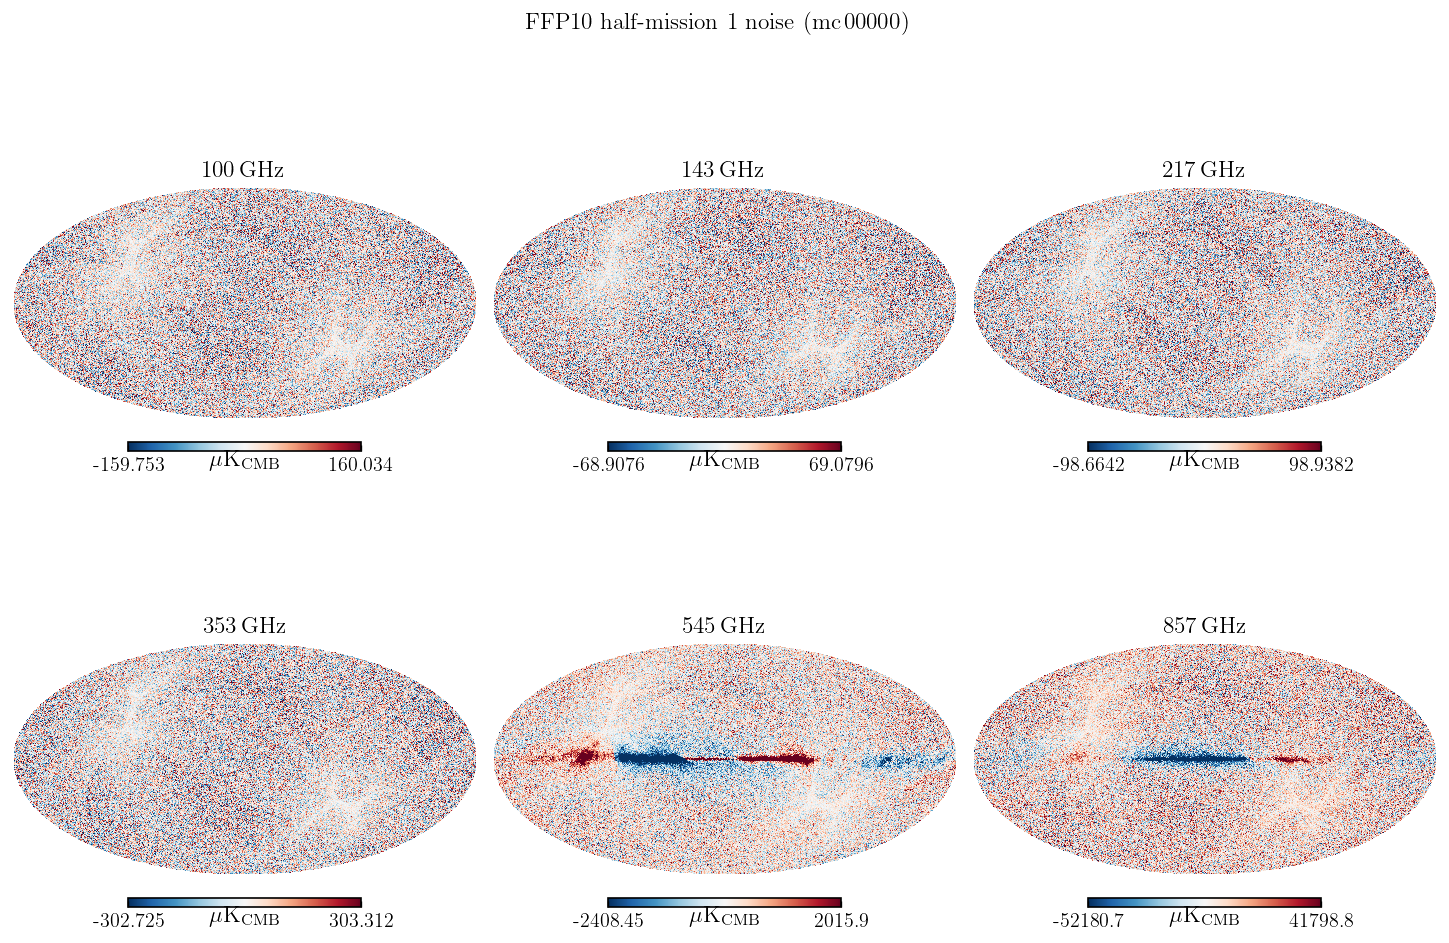

In [4]:
def mollweide_gallery(split: str, fname: str, title: str) -> None:
    fig = plt.figure(figsize=(12.0, 7.6))
    for i, freq in enumerate(FREQUENCIES):
        m = load_T_uK(freq, split)
        lo, hi = np.percentile(m, [1.0, 99.0])
        hp.mollview(
            m,
            fig=fig.number,
            sub=(2, 3, i + 1),
            title=rf"{freq:g}\,GHz",
            unit=r"$\mu\mathrm{K}_\mathrm{CMB}$",
            min=lo,
            max=hi,
            cmap="RdBu_r",
            notext=True,
            cbar=True,
        )
        del m
    fig.suptitle(title, y=1.02, fontsize=14)
    no_grid()
    savefig(fig, fname, fig_dir=FIG_DIR)
    plt.show()


mollweide_gallery(
    "hm1",
    "ffp10_hm1_noise_gallery_mc00000",
    r"FFP10 half-mission 1 noise  ($\mathrm{mc\,00000}$)",
)


Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm2_noise_gallery_mc00000.pdf
Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm2_noise_gallery_mc00000.png


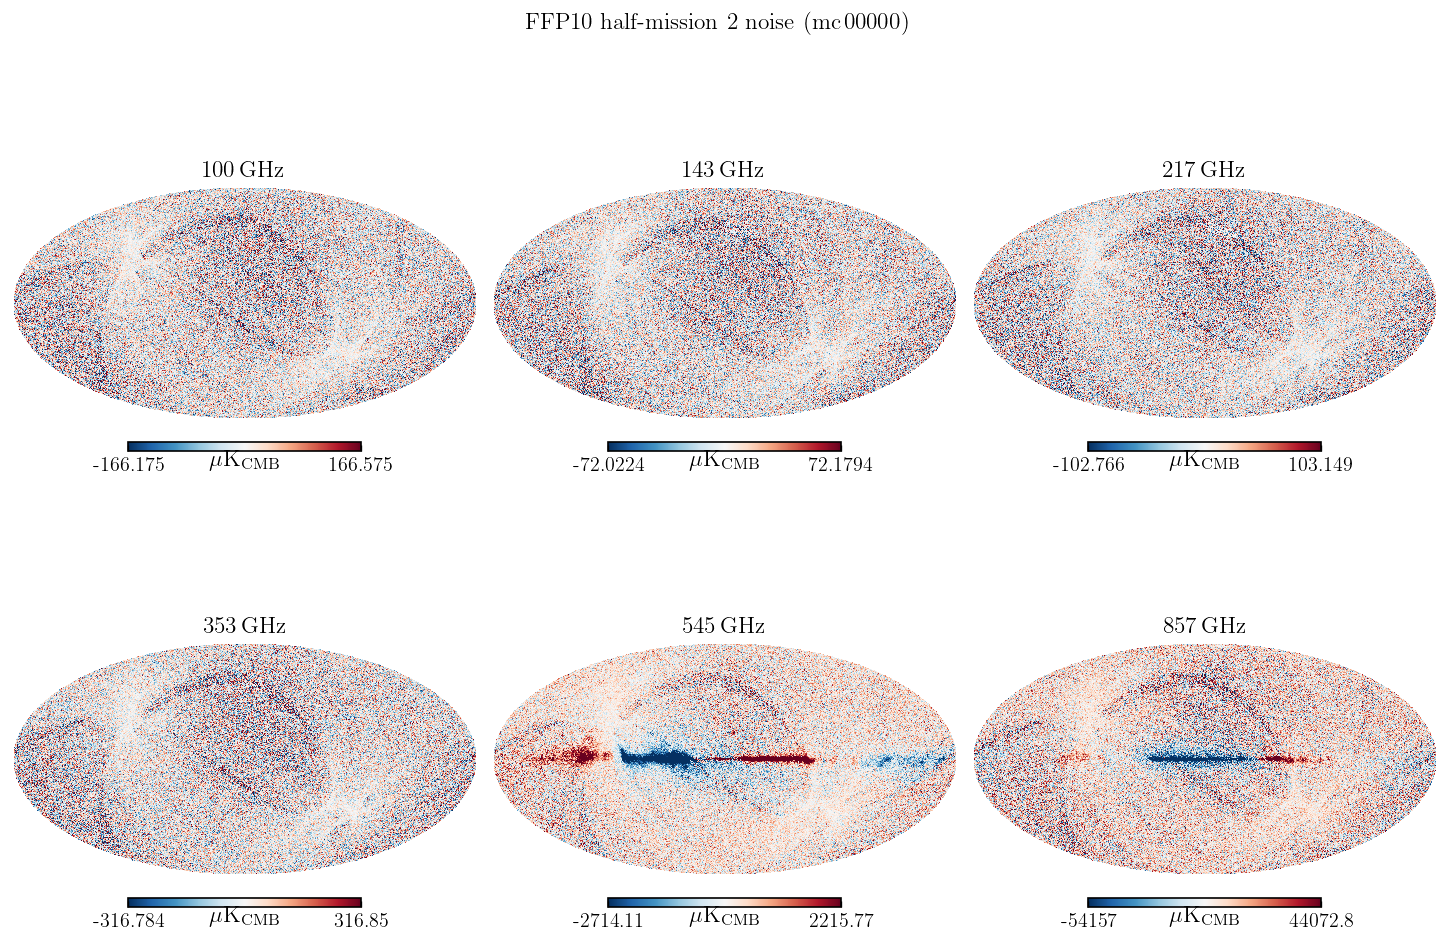

In [5]:
mollweide_gallery(
    "hm2",
    "ffp10_hm2_noise_gallery_mc00000",
    r"FFP10 half-mission 2 noise  ($\mathrm{mc\,00000}$)",
)


### HM1 $-$ HM2 difference

Independent halves $\Rightarrow$ the difference is $\sqrt{2}$ noisier than a single half and should show the same scanning pattern with no coherent sky signal.


   nu     rms HM1     rms HM2   rms HM1-HM2      corr


  100      66.337      67.091        94.339    0.0002
  143      28.659      29.089        40.818    0.0008
  217      40.975      41.429        58.254    0.0005
  353     125.765     127.834       179.263    0.0007
  545    1058.107    1233.966      1147.951    0.5072
  857   20391.051   20327.456     25587.686    0.2102
Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm1_minus_hm2_noise_mc00000.pdf
Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm1_minus_hm2_noise_mc00000.png


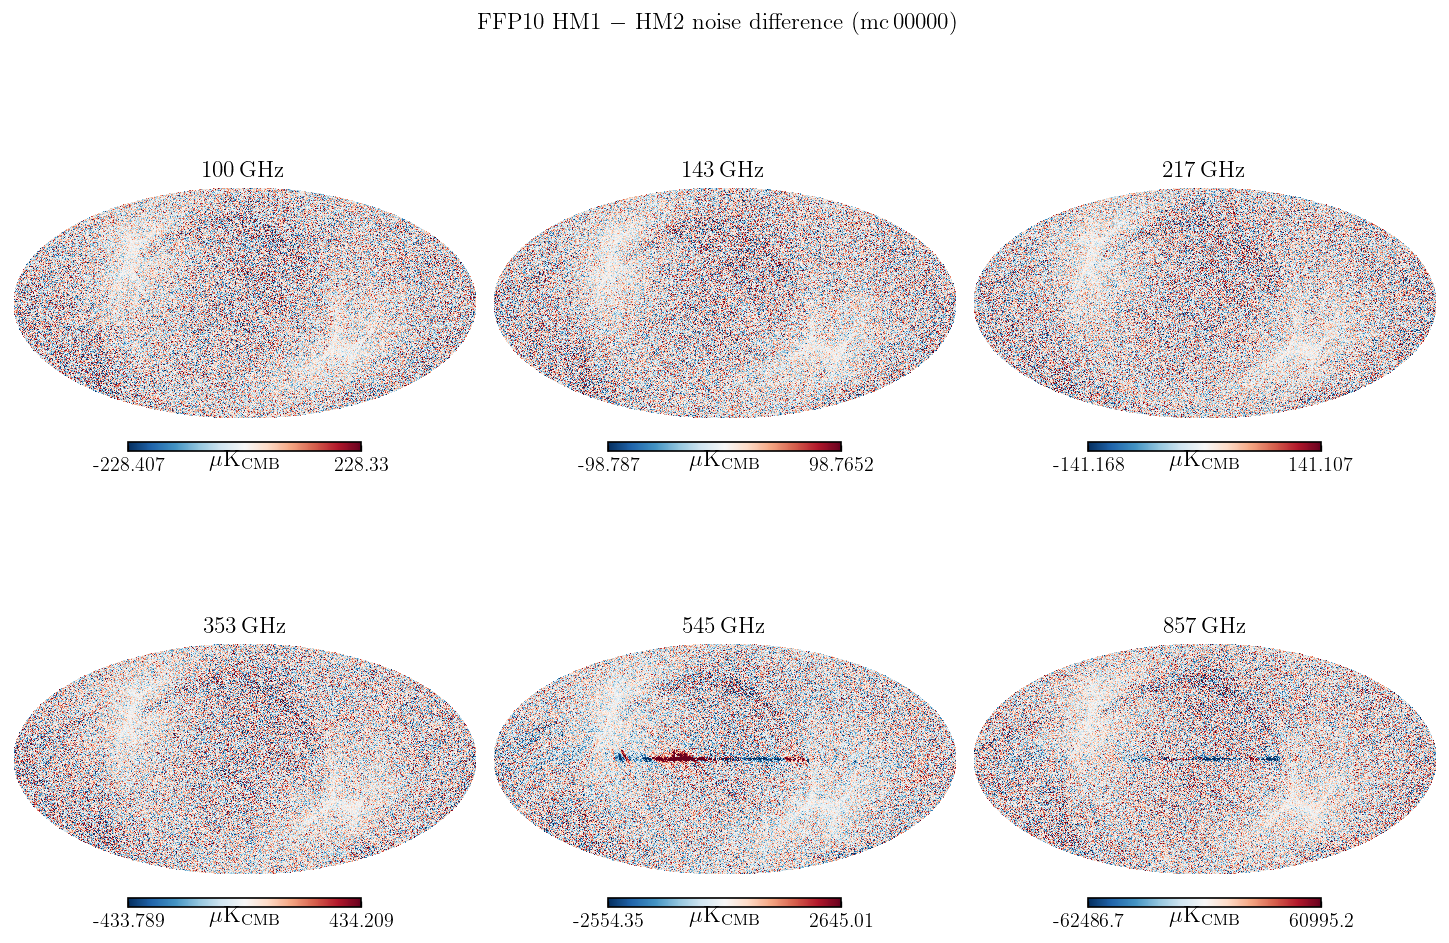

In [6]:
fig = plt.figure(figsize=(12.0, 7.6))
print(f"{'nu':>5}  {'rms HM1':>10}  {'rms HM2':>10}  {'rms HM1-HM2':>12}  {'corr':>8}")
for i, freq in enumerate(FREQUENCIES):
    a = load_T_uK(freq, "hm1")
    b = load_T_uK(freq, "hm2")
    d = a - b
    corr = float(np.corrcoef(a, b)[0, 1])
    print(
        f"{freq:5d}  {a.std():10.3f}  {b.std():10.3f}  {d.std():12.3f}  {corr:8.4f}"
    )
    lo, hi = np.percentile(d, [1.0, 99.0])
    hp.mollview(
        d,
        fig=fig.number,
        sub=(2, 3, i + 1),
        title=rf"{freq:g}\,GHz",
        unit=r"$\mu\mathrm{K}_\mathrm{CMB}$",
        min=lo,
        max=hi,
        cmap="RdBu_r",
        notext=True,
    )
    del a, b, d
fig.suptitle(r"FFP10 HM1 $-$ HM2 noise difference  ($\mathrm{mc\,00000}$)", y=1.02, fontsize=14)
no_grid()
savefig(fig, "ffp10_hm1_minus_hm2_noise_mc00000", fig_dir=FIG_DIR)
plt.show()


## 5. Full-sky auto and HM1 $\times$ HM2 cross spectra

Spectra are cached in `CL_CACHE`. Set `RECOMPUTE_CL = True` to force a fresh `anafast` pass.

For independent half-mission noise, $C_\ell^{\mathrm{HM1}\times\mathrm{HM2}}$ should sit well below the autos (a null). Residual low-$\ell$ correlation can remain from shared scanning / destriping systematics.


In [7]:
need = [f"cl_{s}_{nu}" for nu in FREQUENCIES for s in ("hm1", "hm2", "x")]
have_cache = CL_CACHE.is_file() and not RECOMPUTE_CL
if have_cache:
    cached = np.load(CL_CACHE)
    have_cache = all(k in cached.files for k in need)
    if have_cache:
        cls = {k: cached[k] for k in cached.files}
        print("loaded", CL_CACHE, "keys:", sorted(cls))

if not have_cache:
    cls = {"ell": np.arange(LMAX + 1, dtype=np.float64)}
    for nu in FREQUENCIES:
        print(f"anafast {nu} GHz HM1 / HM2 / cross ...", flush=True)
        a = load_T_uK(nu, "hm1", conv=CONV_CL)
        b = load_T_uK(nu, "hm2", conv=CONV_CL)
        cls[f"cl_hm1_{nu}"] = compute_cl(a, lmax=LMAX, deconv_pixel_window=False)
        cls[f"cl_hm2_{nu}"] = compute_cl(b, lmax=LMAX, deconv_pixel_window=False)
        cls[f"cl_x_{nu}"] = compute_cl(a, b, lmax=LMAX, deconv_pixel_window=False)
        del a, b
    np.savez(CL_CACHE, **cls)
    print("wrote", CL_CACHE)


loaded /rds/rds-lxu/flamingo/integrated_maps_synthetic/planck_noise/half_mission/spectra_ffp10_hm_mc00000_plik.npz keys: ['cl_hm1_100', 'cl_hm1_143', 'cl_hm1_217', 'cl_hm1_353', 'cl_hm1_545', 'cl_hm1_857', 'cl_hm2_100', 'cl_hm2_143', 'cl_hm2_217', 'cl_hm2_353', 'cl_hm2_545', 'cl_hm2_857', 'cl_x_100', 'cl_x_143', 'cl_x_217', 'cl_x_353', 'cl_x_545', 'cl_x_857', 'ell']


### Planck $U_c$ vs monochromatic $dB_\nu/dT$ on $C_\ell$

100–353 GHz are unchanged (already $K_\mathrm{CMB}$). At 545/857 the two conversions differ by a **scalar**, so
$C_\ell^\mathrm{mono} = (uK_\mathrm{mono}/uK_\mathrm{Plik})^2\,C_\ell^\mathrm{Plik}$
with no extra `anafast`. Spectra above/below use Plik; this panel only compares the two unit conventions.


Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm_545_857_uc_vs_mono_cl.pdf
Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm_545_857_uc_vs_mono_cl.png


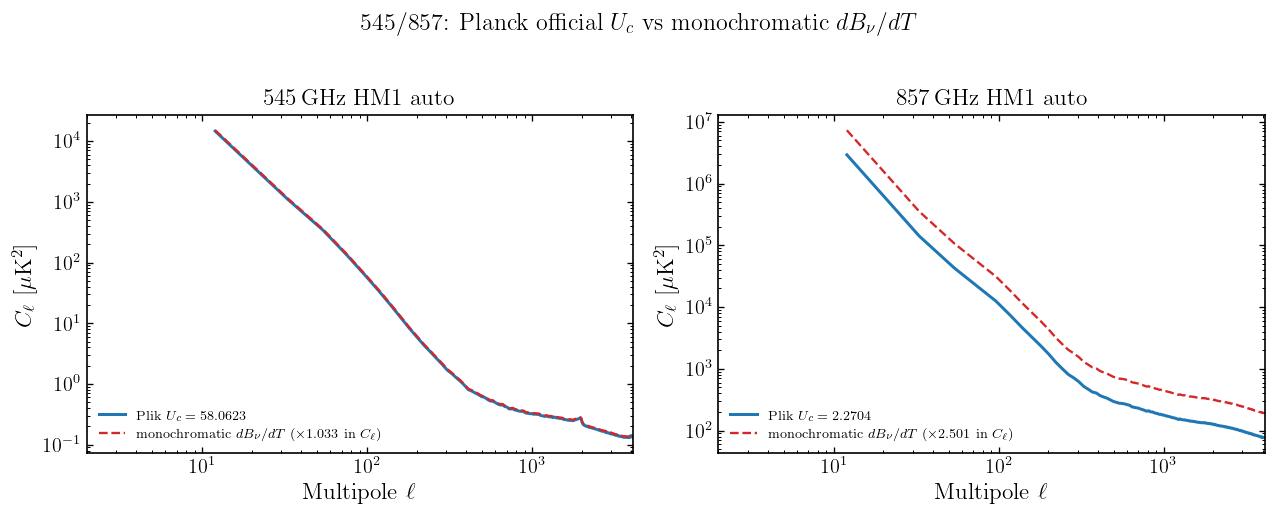

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), sharex=True)
for ax, nu in zip(axes, (545, 857)):
    dBdT = dB_dT_Jy_per_sr_per_K(nu) / 1.0e6
    ratio = (1.0e6 / dBdT) / (1.0e6 / UC_MJY_PER_KCMB[nu])
    e, c_cached = bin_cl(cls[f"cl_hm1_{nu}"], delta_ell=DELTA_ELL, lmin=2)
    if CONV_CL == "plik":
        c_plik, c_mono = c_cached, c_cached * ratio ** 2
    elif CONV_CL == "mono":
        c_mono, c_plik = c_cached, c_cached / ratio ** 2
    else:
        raise ValueError(CONV_CL)
    ax.loglog(e, c_plik, color="C0", lw=1.8, label=rf"Plik $U_c={UC_MJY_PER_KCMB[nu]:.4f}$")
    ax.loglog(e, c_mono, color="C3", lw=1.4, ls="--", label=rf"monochromatic $dB_\nu/dT$ ($\times{ratio**2:.3f}$ in $C_\ell$)")
    ax.set_title(rf"{nu:g}\,GHz HM1 auto")
    ax.set_xlim(2, LMAX)
    ax.set_xlabel(r"Multipole $\ell$")
    ax.set_ylabel(r"$C_\ell$ [$\mu\mathrm{K}^2$]")
    ax.legend(loc="lower left", fontsize=8)
    no_grid(ax)
fig.suptitle(r"545/857: Planck official $U_c$ vs monochromatic $dB_\nu/dT$", y=1.02)
fig.tight_layout()
savefig(fig, "ffp10_hm_545_857_uc_vs_mono_cl", fig_dir=FIG_DIR)
plt.show()


### Per-frequency $C_\ell$: auto vs cross

Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm_noise_cl_auto_cross_mc00000.pdf
Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm_noise_cl_auto_cross_mc00000.png


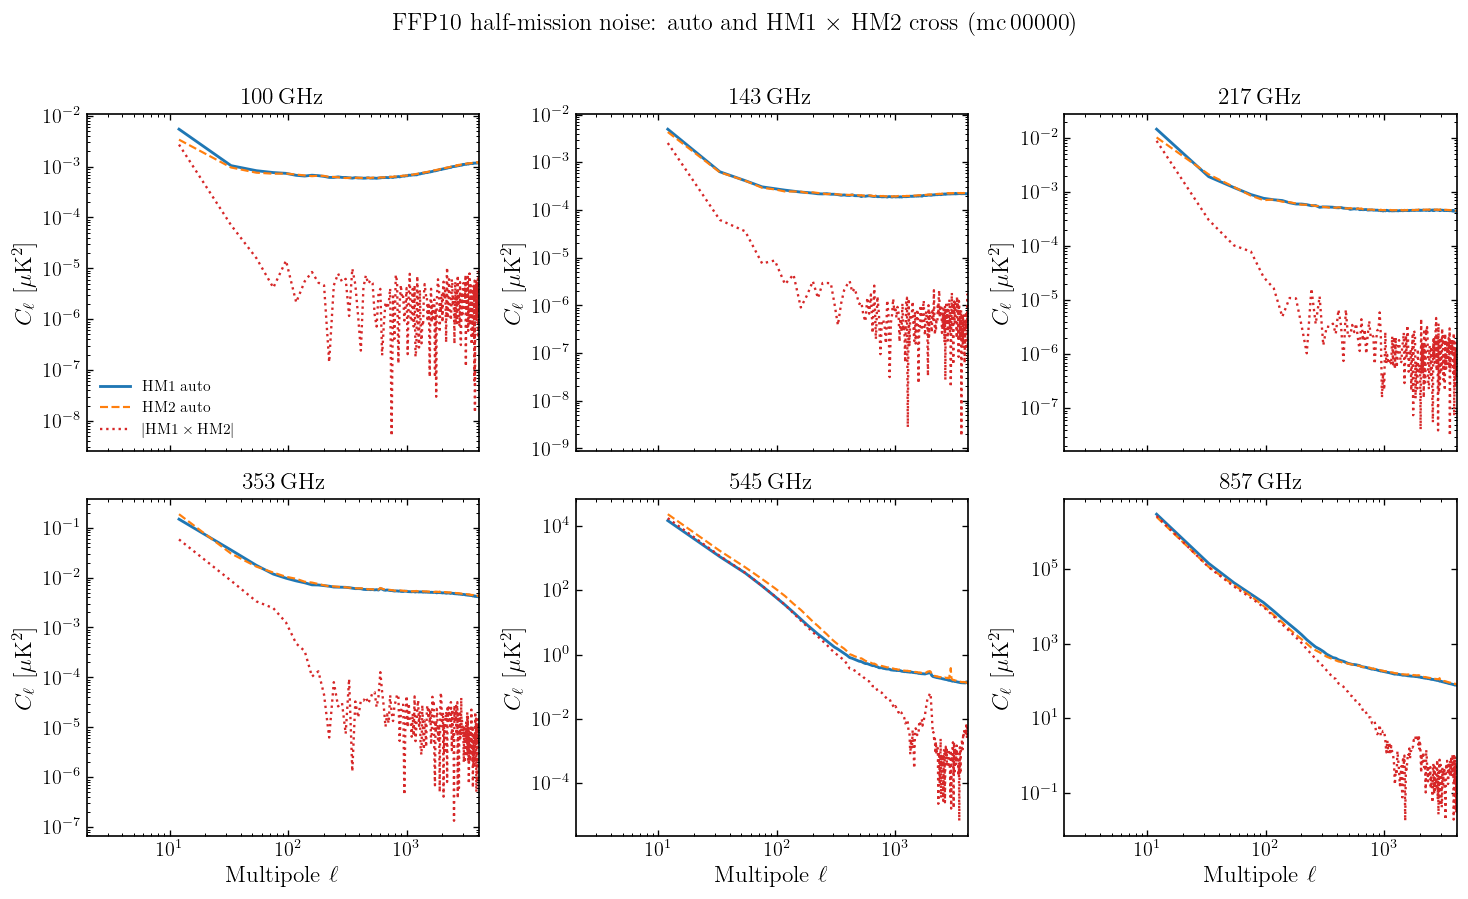

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12.4, 7.4), sharex=True)
axes = axes.ravel()
for ax, nu in zip(axes, FREQUENCIES):
    e1, c1 = bin_cl(cls[f"cl_hm1_{nu}"], delta_ell=DELTA_ELL, lmin=2)
    e2, c2 = bin_cl(cls[f"cl_hm2_{nu}"], delta_ell=DELTA_ELL, lmin=2)
    ex, cx = bin_cl(cls[f"cl_x_{nu}"], delta_ell=DELTA_ELL, lmin=2)
    ax.loglog(e1, c1, color="C0", lw=1.7, label=r"HM1 auto")
    ax.loglog(e2, c2, color="C1", lw=1.3, ls="--", label=r"HM2 auto")
    ax.loglog(ex, np.abs(cx), color="C3", lw=1.4, ls=":", label=r"$|\mathrm{HM1}\times\mathrm{HM2}|$")
    ax.set_title(rf"{nu:g}\,GHz")
    ax.set_xlim(2, LMAX)
    ax.set_ylabel(r"$C_\ell$ [$\mu\mathrm{K}^2$]")
    no_grid(ax)
axes[0].legend(loc="lower left", fontsize=9)
for ax in axes[3:]:
    ax.set_xlabel(r"Multipole $\ell$")
fig.suptitle(
    r"FFP10 half-mission noise: auto and HM1 $\times$ HM2 cross  ($\mathrm{mc\,00000}$)",
    y=1.01,
)
fig.tight_layout()
savefig(fig, "ffp10_hm_noise_cl_auto_cross_mc00000", fig_dir=FIG_DIR)
plt.show()


### All-frequency overlay and cross-correlation coefficient

Left: HM1 auto-spectra, all six channels. Right: $r_\ell = C_\ell^{\mathrm{HM1}\times\mathrm{HM2}} / \sqrt{C_\ell^{\mathrm{HM1}} C_\ell^{\mathrm{HM2}}}$ (independent noise $\Rightarrow$ $r_\ell\approx 0$).


Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm_noise_cl_overlay_r_mc00000.pdf
Wrote /scratch/scratch-lxu/flamingo_mock_analysis/figures/ffp10_hm_noise_cl_overlay_r_mc00000.png


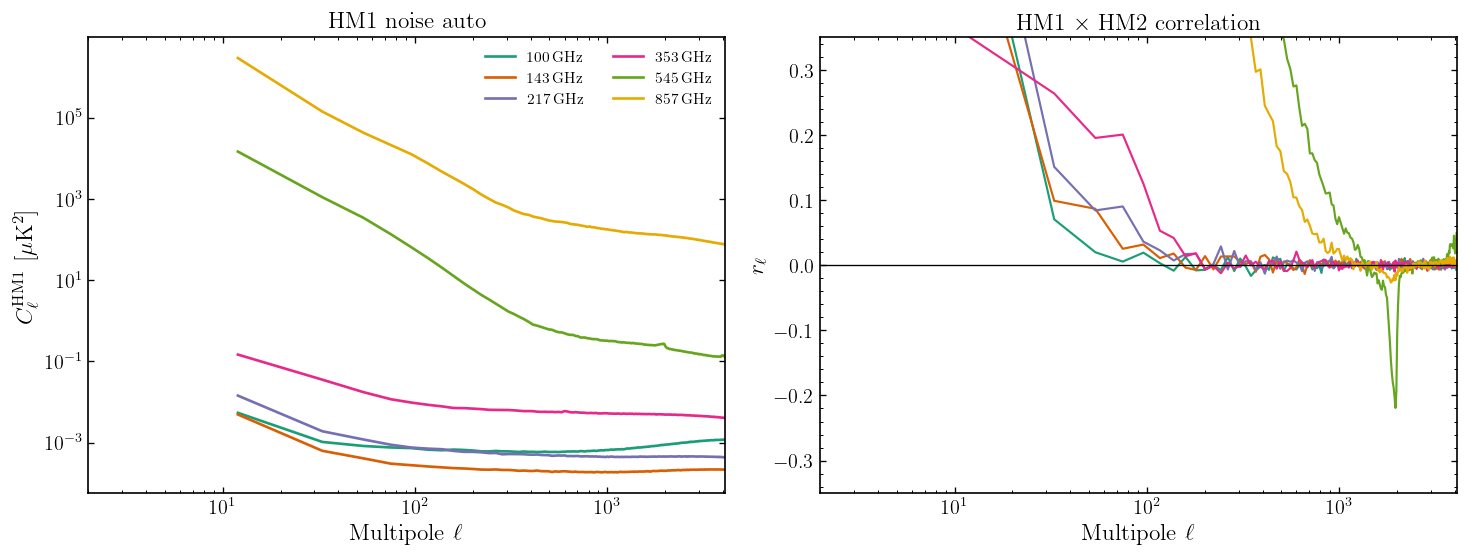

In [10]:
colors = {
    100: "#1b9e77",
    143: "#d95f02",
    217: "#7570b3",
    353: "#e7298a",
    545: "#66a61e",
    857: "#e6ab02",
}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.4, 4.8))
for nu in FREQUENCIES:
    e, c = bin_cl(cls[f"cl_hm1_{nu}"], delta_ell=DELTA_ELL, lmin=2)
    axL.loglog(e, c, color=colors[nu], lw=1.6, label=rf"{nu:g}\,GHz")
axL.set_xlim(2, LMAX)
axL.set_xlabel(r"Multipole $\ell$")
axL.set_ylabel(r"$C_\ell^{\mathrm{HM1}}$ [$\mu\mathrm{K}^2$]")
axL.set_title(r"HM1 noise auto")
axL.legend(loc="upper right", ncol=2, fontsize=9)
no_grid(axL)

for nu in FREQUENCIES:
    e1, c1 = bin_cl(cls[f"cl_hm1_{nu}"], delta_ell=DELTA_ELL, lmin=2)
    _, c2 = bin_cl(cls[f"cl_hm2_{nu}"], delta_ell=DELTA_ELL, lmin=2)
    _, cx = bin_cl(cls[f"cl_x_{nu}"], delta_ell=DELTA_ELL, lmin=2)
    den = np.sqrt(np.clip(c1, 0, None) * np.clip(c2, 0, None))
    r = np.full_like(cx, np.nan)
    good = den > 0
    r[good] = cx[good] / den[good]
    axR.plot(e1, r, color=colors[nu], lw=1.3, label=rf"{nu:g}\,GHz")
axR.axhline(0.0, color="k", lw=0.8)
axR.set_xscale("log")
axR.set_xlim(2, LMAX)
axR.set_ylim(-0.35, 0.35)
axR.set_xlabel(r"Multipole $\ell$")
axR.set_ylabel(r"$r_\ell$")
axR.set_title(r"HM1 $\times$ HM2 correlation")
no_grid(axR)

fig.tight_layout()
savefig(fig, "ffp10_hm_noise_cl_overlay_r_mc00000", fig_dir=FIG_DIR)
plt.show()


### High-$\ell$ summary

Mean $C_\ell$ over $500\le\ell\le 2000$ and mean $r_\ell$ over the same range.


In [11]:
ell = np.arange(LMAX + 1)
band = (ell >= 500) & (ell <= 2000)
print(f"{'nu':>5}  {'<C_HM1>':>12}  {'<C_HM2>':>12}  {'<|C_x|>':>12}  {'<r>':>8}  {'rms r':>8}")
print(f"{'GHz':>5}  {'uK^2':>12}  {'uK^2':>12}  {'uK^2':>12}")
for nu in FREQUENCIES:
    c1 = cls[f"cl_hm1_{nu}"][band]
    c2 = cls[f"cl_hm2_{nu}"][band]
    cx = cls[f"cl_x_{nu}"][band]
    r = cx / np.sqrt(np.clip(c1, 0, None) * np.clip(c2, 0, None))
    print(
        f"{nu:5d}  {np.nanmean(c1):12.4e}  {np.nanmean(c2):12.4e}  "
        f"{np.nanmean(np.abs(cx)):12.4e}  {np.nanmean(r):8.4f}  {np.nanstd(r):8.4f}"
    )


   nu       <C_HM1>       <C_HM2>       <|C_x|>       <r>     rms r
  GHz          uK^2          uK^2          uK^2
  100    7.2164e-04    7.3650e-04    1.2171e-05    0.0002    0.0220
  143    1.9430e-04    2.0004e-04    3.4005e-06    0.0005    0.0220
  217    4.5691e-04    4.6549e-04    7.9746e-06    0.0009    0.0217
  353    5.2361e-03    5.3746e-03    8.9827e-05    0.0013    0.0215
  545    3.2236e-01    3.5874e-01    4.0420e-02    0.0394    0.1277
  857    1.7076e+02    1.7784e+02    7.0880e+00    0.0175    0.0467
